In [2]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

import eurostat #python wrapper for taking data. 
import time

In [3]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals'

In [4]:
import os
os.chdir(Share_point)

In [5]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

In [6]:
Points_APIs = pd.read_excel(r'Dataproviders 09.05.2023.xlsx',sheet_name='LNG terminals')

### key for version 6 and 7 of the API calls GIE

In [14]:
headers = {"x-key":"d8561648296cb38e6c400823755689941530"} # After July 4th 2022

### Restart here

In [15]:
d1 = '2023-08-01'
d2 = '2023-12-31' # To change in the new year

In [16]:
dates = []
sendOut = []
stored = []
max_storage = []
max_sendout =[]
country = []
Name = []

for item in range(len(Points_APIs)):
        url = Points_APIs.iloc[item,3]+'&from={}&to={}&size=300'.format(d1,d2)
        try:
            r = requests.get(url,headers=headers)
            if r.status_code != 200:
                print(r.status_code)
                print(url)

            raw_data = r.json()
            inner_data = raw_data['data']
            for x in inner_data:
                #here we work with the APIs
                date = x['gasDayStart'] 
                inventory = x['inventory']
                sendOuts = x['sendOut']
                Max_Storage = x['dtmi']
                Max_Sendout = x['dtrs']
                #here we work with the excel file
                countries = Points_APIs.iloc[item,0]
                Names = Points_APIs.iloc[item,5]


                dates.append(date)     
                sendOut.append(sendOuts)
                stored.append(inventory)
                max_storage.append(Max_Storage)
                max_sendout.append(Max_Sendout)
                country.append(countries)
                Name.append(Names)
        except Exception as e:
            print(e)

In [17]:
df = pd.DataFrame()
df['dates'] = dates
df['sendOut'] = sendOut          ## in GWh/d
df['stored'] = stored            ## in 10^3 m^3 LNG
df['Max Storage'] = max_storage  ## in 10^3 m^3 LNG
df['Max Sendout'] = max_sendout  ## in GWh/d
df['country'] = country
df['name'] = Name

In [18]:
# Getting rid of NaNa
df.replace('-', np.NaN,inplace=True)
# Getting rid of observations for which we have no data
df = df.dropna()

In [19]:
df['sendOut'] = pd.to_numeric(df['sendOut'])
df['stored'] = pd.to_numeric(df['stored'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 
df['Max Sendout'] = pd.to_numeric(df['Max Sendout']) 

In [20]:
df.head()

,dates,sendOut,stored,Max Storage,Max Sendout,country,name
0,2023-09-03,257.4,209.24,566.0,541.0,BE,Zeebrugge LNG Terminal
1,2023-09-02,252.8,249.69,566.0,541.0,BE,Zeebrugge LNG Terminal
2,2023-09-01,347.4,290.20,566.0,541.0,BE,Zeebrugge LNG Terminal
3,2023-08-31,332.6,336.50,566.0,541.0,BE,Zeebrugge LNG Terminal
4,2023-08-30,252.5,406.91,566.0,541.0,BE,Zeebrugge LNG Terminal


In [21]:
from datetime import date
df.to_csv('raw_data/2023_2.csv')

###  merge with historic data

In [7]:
# Change current directory
import os
os.chdir(Share_point + '\\raw_data')

In [8]:
df_5a = pd.read_csv('2019_1.csv',index_col=0)
df_5b = pd.read_csv('2019_2.csv',index_col=0)
df_6a = pd.read_csv('2020_1.csv',index_col=0)
df_6b = pd.read_csv('2020_2.csv',index_col=0)
df_7a = pd.read_csv('2021_1.csv',index_col=0)
df_7b = pd.read_csv('2021_2.csv',index_col=0)
df_8a = pd.read_csv('2022_1.csv',index_col=0)
df_8b = pd.read_csv('2022_2.csv',index_col=0)
df_9a = pd.read_csv('2023_1.csv',index_col=0)
df_9b = pd.read_csv('2023_2.csv',index_col=0)

In [9]:
df = pd.concat([df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b])

In [10]:
# del df['Unnamed: 0']
df = df.drop_duplicates()

In [11]:
from datetime import date
today = date.today()
last_obs = today - timedelta(days=3)

In [12]:
df[df['dates']==str(last_obs)].head()

,dates,sendOut,stored,Max Storage,Max Sendout,country,name


In [13]:
df = df.set_index(pd.DatetimeIndex(df['dates']))

In [14]:
del df['dates']

In [15]:
df = df.sort_values(by='dates')

In [16]:
df.country.unique()

array(['FR', 'IT', 'ES', 'LT', 'PL', 'NL', 'GB', 'BE', 'GR', 'PT', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)

In [17]:
# Change current directory
import os
os.chdir(Share_point)

In [18]:
df_C = df.groupby(['dates','country']).sum().reset_index()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_12076\146117598.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_C = df.groupby(['dates','country']).sum().reset_index()


In [19]:
df_C = df_C.set_index(pd.DatetimeIndex(df_C['dates']))

In [20]:
from datetime import date
today = date.today()
last_obs = today - timedelta(days=2)
print(last_obs)
# enddate = datetime.strptime('2022-07-17', "%d-%m-%Y")
enddate = last_obs
startdate = enddate - timedelta(days=30)

2023-09-05


### Weekly data

In [36]:
df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_29244\1569378660.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()


In [37]:
df_w=df_w.set_index(pd.DatetimeIndex(df_w['dates']))

In [38]:
df_w.country.unique()

array(['BE', 'ES', 'FR', 'GB', 'GR', 'IT', 'LT', 'NL', 'PL', 'PT', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)

In [39]:
df_w = df_w[~df_w.country.isin(['ES*','GB','GB*'])] # Get rid of UK and ES TVB aggregate for which there are no data pre-2020

In [40]:
del df_w['dates']

In [41]:
## Can change from new year
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

# plot = df_w.groupby([pd.Grouper(freq='W'),'country']).sum()[:] ## use a converter if you want to transform the data
df_w['week'] = df_w.index.isocalendar().week

hist = df_w['2019-01-05':'2022-01-02'].groupby(['country','week']).mean().reset_index()
values2021 = df_w.loc['2019-12-28':'2022-01-02'].groupby(['country','week']).max().reset_index()
values2022 = df_w.loc['2022-01-03':'2023-01-01'].groupby(['country','week']).max().reset_index()
values2023 = df_w.loc['2023-01-01':'2023-12-31'].groupby(['country','week']).max().reset_index()

In [42]:
hist['regas %'] = (hist['sendOut']/hist['Max Sendout'])*100
values2021['regas %'] = (values2021['sendOut']/values2021['Max Sendout'])*100
values2022['regas %'] = (values2022['sendOut']/values2022['Max Sendout'])*100
values2023['regas %'] = (values2023['sendOut']/values2023['Max Sendout'])*100

In [43]:
import os
os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')

In [44]:
Excelwriter = pd.ExcelWriter(r"GIE ALSI LNG terminals\LNG_GIE_weekly_data {}.xlsx".format(today),engine="xlsxwriter")
hist.to_excel(Excelwriter, sheet_name="2019-2021", index=False)
values2021.to_excel(Excelwriter, sheet_name="2021", index=False)
values2022.to_excel(Excelwriter, sheet_name="2022", index=False)
values2023.to_excel(Excelwriter, sheet_name="2023", index=False)
Excelwriter.close()
Excelwriter.save()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_29244\1029837468.py:7: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  Excelwriter.save()
c:\Users\giovanni.sgaravatti\anaconda3\lib\site-packages\xlsxwriter\workbook.py:339: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


# Checks

Monthly

In [21]:
cplot = df.loc[~df['country'].str.startswith('GB')]

In [25]:
cplot_month =  cplot.groupby([pd.Grouper(freq='M'),'country']).sum(numeric_only=True).reset_index() #/converter

In [26]:
cmonth.country.unique()

array(['BE', 'ES', 'FR', 'GR', 'IT', 'LT', 'NL', 'PL', 'PT', 'ES*', 'HR',
       'DE'], dtype=object)

In [27]:
cplot_month['M3m'] = round(cplot_month['sendOut']/10.3,1)
print(cmonth.tail())

         dates country  sendOut   stored  Max Storage  Max Sendout    M3m
590 2023-09-30      IT   1604.1   870.21      1386.48       1680.9  155.7
591 2023-09-30      LT    292.6   350.88       500.19        349.2   28.4
592 2023-09-30      NL   1937.0  1794.52      2085.63       2304.6  188.1
593 2023-09-30      PL    599.6   380.65       960.00        660.0   58.2
594 2023-09-30      PT    415.7   950.26      1170.00        600.0   40.4


In [28]:
cmonth = pd.pivot_table(cplot_month,values='M3m',index='dates',columns='country')

In [39]:
cmonth= cmonth[:'2023-02']

In [46]:
cmonth.columns

Index(['BE', 'DE', 'ES', 'ES*', 'FR', 'GR', 'HR', 'IT', 'LT', 'NL', 'PL',
       'PT'],
      dtype='object', name='country')

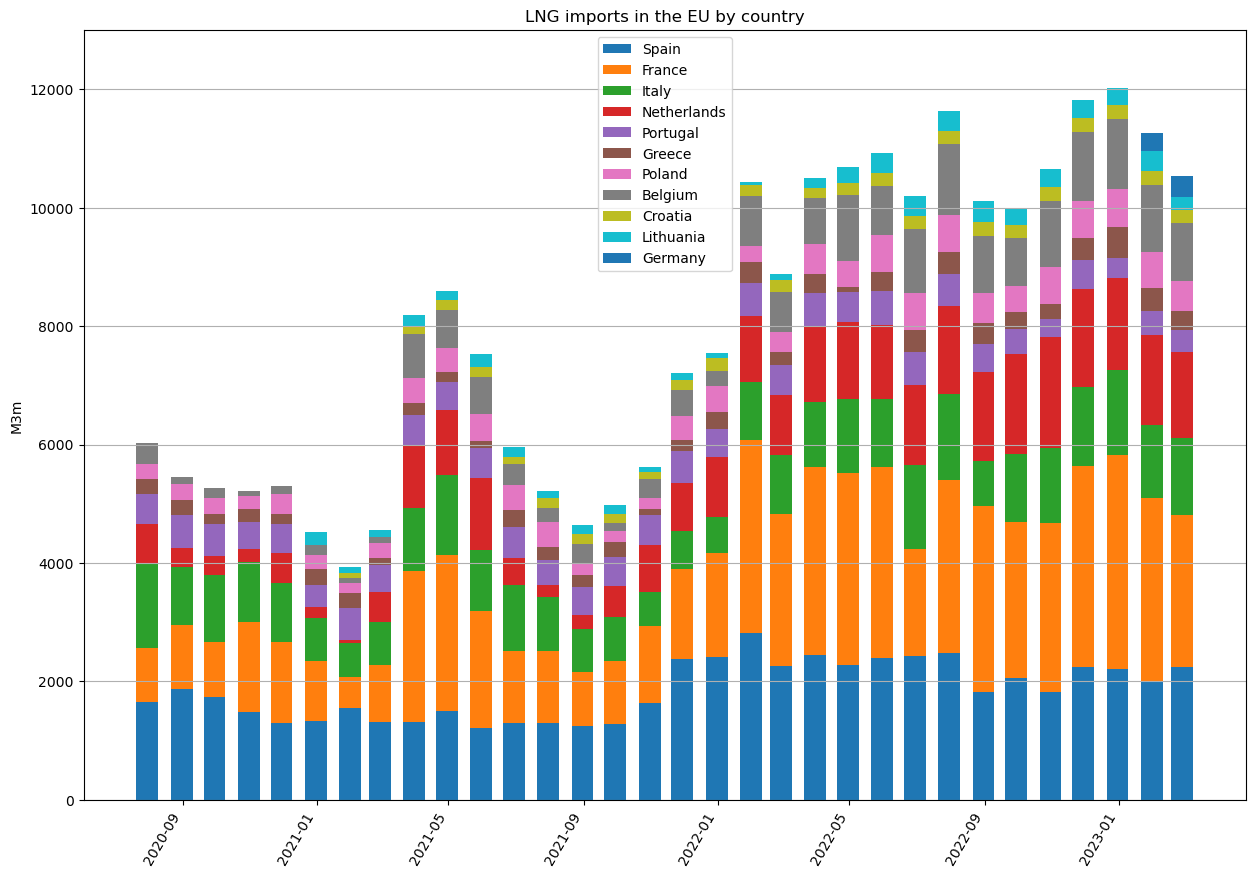

In [54]:
x = cmonth.index
width = 20       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(15,10))

ax.bar(x, cmonth['ES*'], width, label='Spain')
ax.bar(x, cmonth['FR'], width, bottom=cmonth['ES*'],
       label='France')
ax.bar(x, cmonth['IT'], width, bottom=cmonth['ES*']+cmonth['FR'],
       label='Italy')
ax.bar(x, cmonth['NL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT'],
       label='Netherlands')
ax.bar(x, cmonth['PT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL'],
       label='Portugal')
ax.bar(x, cmonth['GR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT'],
       label='Greece')
ax.bar(x, cmonth['PL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR'],
       label='Poland')
ax.bar(x, cmonth['BE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL'],
       label='Belgium')
ax.bar(x, cmonth['HR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE'],
label='Croatia')
ax.bar(x, cmonth['LT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR'],
label='Lithuania')
ax.bar(x, cmonth['DE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR']+cmonth['LT'],
label='Germany')
fig.set_facecolor('white')

plt.setp(ax.get_xticklabels(), rotation=60, horizontalalignment='right')

ax = plt.gca()
ax.set_ylim([0, 13000])
ax.grid(axis='y')

ax.set_ylabel('M3m')
ax.set_title('LNG imports in the EU by country')
ax.legend()

plt.show()

Weekly

In [35]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

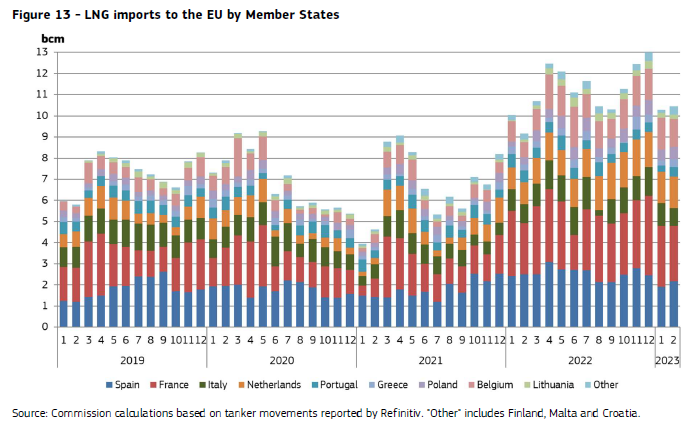

In [44]:
from IPython.display import Image, display
display(Image("Commission Qreport 2023.png",width=1200))

In [32]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

In [180]:
cplot = df.loc[~df['country'].isin(['ES','GB','GB*'])] # getting rid of Spain granular data as ES* is TVB --> virtual balanging LNG for all country's terminals

In [33]:
cplot.to_csv('AGSI.csv')

In [181]:
cplot.country.unique()

array(['FR', 'IT', 'LT', 'PL', 'NL', 'BE', 'GR', 'PT', 'ES*', 'HR', 'DE'],
      dtype=object)

In [182]:
cplot_week = cplot.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
cplot_week['week'] = cplot_week.index.isocalendar().week

In [183]:
cplot_week['M3m']=round(cplot_week['sendOut']/10.3,1)

<Axes: xlabel='dates'>

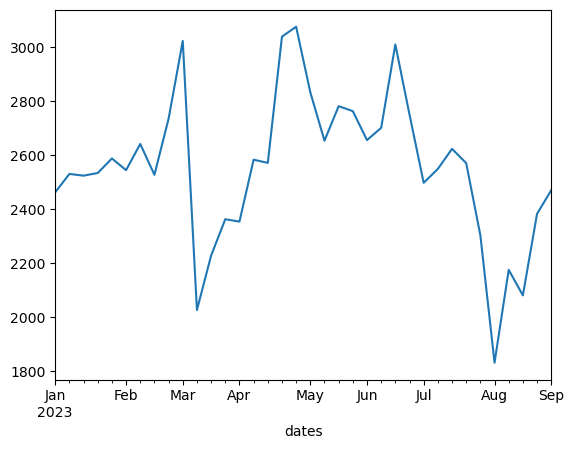

In [186]:
cplot_week['M3m']['2023':].plot()